In [1]:
!pip install kaggle --quiet
import os

# Create .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# IMPORTANT: You need to upload your kaggle.json API token to Colab's file system.
# You can get this from your Kaggle account settings:
# 1. Go to Kaggle website.
# 2. Click on your profile picture, then 'Account'.
# 3. Scroll down to 'API' section and click 'Create New API Token'.
# 4. A file named kaggle.json will be downloaded.
# 5. In Colab, click on the folder icon (File browser) on the left sidebar.
# 6. Click 'Upload to session storage' icon and upload your kaggle.json file.

# Copy kaggle.json to the .kaggle directory
# This assumes kaggle.json is in the current working directory or has been uploaded to Colab's session storage.
# If you uploaded it, it will typically be in /content/kaggle.json
!cp kaggle.json ~/.kaggle/

# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset using Kaggle API
# The dataset name is 'andrewmvd/animal-faces'
!kaggle datasets download -d andrewmvd/animal-faces

# Unzip the downloaded file
# The downloaded file will be named 'animal-faces.zip' by default for this dataset
!unzip -q animal-faces.zip -d animal-faces

print("Dataset downloaded and unzipped successfully into 'animal-faces' directory.")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 696M/696M [00:07<00:00, 93.7MB/s]

Dataset downloaded and unzipped successfully into 'animal-faces' directory.


In [2]:
!ls animal-faces

afhq


In [3]:
!ls animal-faces/afhq

train  val


In [4]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset , DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import numpy as np
import os

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
device

'cuda'

In [7]:
import os
import pandas as pd
image_path = []
labels = []
for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)
data_df = pd.DataFrame(zip(image_path,labels),columns= ["image_path","labels"])
print(data_df["labels"].unique())
data_df.head()

['cat' 'wild' 'dog']


,image_path,labels
0,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
1,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
2,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
3,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
4,/content/animal-faces/afhq/train/cat/pixabay_c...,cat


In [8]:
train = data_df.sample(frac=0.7)
test = data_df.drop(train.index)

val  = test.sample(frac=0.5)
test = test.drop(val.index)

print("train shape : ",train.shape)
print("test shape : ",test.shape)
print("val shape : ",val.shape)

train shape :  (11291, 2)
test shape :  (2419, 2)
val shape :  (2420, 2)


In [9]:
labelencoder = LabelEncoder()
labelencoder.fit(data_df["labels"])

transform= transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [30]:
class CustomImageDataset(Dataset):
  def __init__(self,dataframe,transform:None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(labelencoder.transform(self.dataframe["labels"])).to(device)
  def __len__(self):
    return self.dataframe.shape[0]
  def __getitem__(self,idx):
    img_path = self.dataframe.iloc[idx,0]
    label = self.labels[idx]
    image = Image.open(img_path).convert("RGB")

    if self.transform:
      image = self.transform(image)
    return image,label

In [31]:
train_dataset = CustomImageDataset(dataframe = train,transform = transform)
val_dataset = CustomImageDataset(dataframe = val,transform = transform)
test_dataset = CustomImageDataset(dataframe = test,transform = transform)

In [32]:
LR = 1e-4
BATCH_Size = 16
EPOCHS=10


In [33]:
train_loader = DataLoader(train_dataset,batch_size=BATCH_Size,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=BATCH_Size,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=BATCH_Size,shuffle=True)

In [34]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3,32,kernel_size=3 , padding = 1)
    self.conv2 = nn.Conv2d(32,64,kernel_size=3,padding = 1)
    self.conv3 = nn.Conv2d(64,128,kernel_size=3,padding = 1)

    self.pooling = nn.MaxPool2d(2,2)
    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()

    self.linear = nn.Linear((128*16*16),128)

    self.output = nn.Linear(128,len(data_df["labels"].unique()))
  def forward(self,x):
    x = self.conv1(x) # -> (32,128,128)
    x = self.pooling(x)# -> (32,64,64)
    x = self.relu(x)

    x = self.conv2(x) # ->(64,64,64)
    x = self.pooling(x) # -> (64,32,32)
    x = self.relu(x)

    x = self.conv3(x) # ->(128,64,64)
    x = self.pooling(x) # -> (128,16,16)
    x = self.relu(x)

    x = self.flatten(x)
    x = self.linear(x)
    x = self.output(x)

    return x


In [35]:
model = Net().to(device)

In [36]:
from torchsummary import summary
summary(model,input_size=(3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [37]:
criterian = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)


In [41]:
total_loss_train_plot= []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot =[]


for epoch in range(EPOCHS):
  total_acc_train = 0
  total_acc_validation = 0
  total_loss_train = 0
  total_loss_validation = 0
  for inputs,labels in train_loader:
    optimizer.zero_grad()
    output = model(inputs.to(device))
    train_loss = criterian(output,labels.to(device))
    total_loss_train += train_loss.item()
    train_loss.backward()
    train_acc = (torch.argmax(output, axis=1)==labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()

  with torch.no_grad():
    for inputs,labels in val_loader:
      output = model(inputs.to(device))
      val_loss = criterian(output,labels.to(device))
      total_loss_validation += val_loss.item()
      val_acc = (torch.argmax(output, axis=1)==labels).sum().item()
      total_acc_validation += val_acc
    total_loss_train_plot.append(round(total_loss_train/1000,4))
    total_loss_validation_plot.append(round(total_loss_validation/1000,4))
    total_acc_train_plot.append(round((total_acc_train/train_dataset.__len__())*100,4 ))
    total_acc_validation_plot.append(round((total_acc_validation/val_dataset.__len__())*100,4))

    print(f'''EPOCH{epoch+1}/{EPOCHS} , Train Loss : {round(total_loss_train/1000,4)} , Validation Loss : {round(total_loss_validation/1000,4)},
    Train Accuracy : {round((total_acc_train/train_dataset.__len__())*100,4)} , Validation Accuracy : {round((total_acc_validation/val_dataset.__len__())*100,4)}''')



EPOCH1/10 , Train Loss : 0.0596 , Validation Loss : 0.0147,
    Train Accuracy : 97.0065 , Validation Accuracy : 96.281
EPOCH2/10 , Train Loss : 0.0472 , Validation Loss : 0.0161,
    Train Accuracy : 97.6353 , Validation Accuracy : 96.0744
EPOCH3/10 , Train Loss : 0.0318 , Validation Loss : 0.0159,
    Train Accuracy : 98.5298 , Validation Accuracy : 95.9504
EPOCH4/10 , Train Loss : 0.023 , Validation Loss : 0.0172,
    Train Accuracy : 98.8664 , Validation Accuracy : 96.0331
EPOCH5/10 , Train Loss : 0.0206 , Validation Loss : 0.0183,
    Train Accuracy : 99.0612 , Validation Accuracy : 95.6198
EPOCH6/10 , Train Loss : 0.0117 , Validation Loss : 0.016,
    Train Accuracy : 99.5129 , Validation Accuracy : 96.4463
EPOCH7/10 , Train Loss : 0.0107 , Validation Loss : 0.0197,
    Train Accuracy : 99.5483 , Validation Accuracy : 95.8678
EPOCH8/10 , Train Loss : 0.0103 , Validation Loss : 0.0242,
    Train Accuracy : 99.4686 , Validation Accuracy : 95.124
EPOCH9/10 , Train Loss : 0.0046 , Va

In [45]:
with torch.no_grad():
  total_loss_test =  0
  total_acc_test = 0
  for inputs, labels in test_loader:
    predictions = model(inputs.to(device))

    acc = (torch.argmax(predictions, axis=1)==labels).sum().item()
    total_acc_test += acc
    test_loss = criterian(predictions,labels.to(device))
    total_loss_test += test_loss.item()

print(f'''
Accuracy : {round((total_acc_test/test_dataset.__len__())*100,4)}
Loss : {round(total_loss_test/1000,4)}
''')


Accuracy : 97.437
Loss : 0.0186



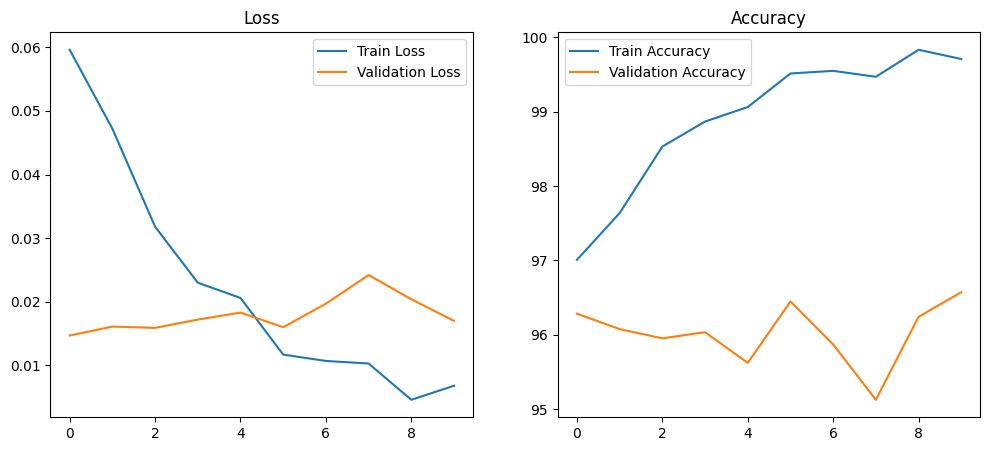

In [49]:
fig , axis = plt.subplots(1,2,figsize=(12,5))
axis[0].plot(total_loss_train_plot,label="Train Loss")
axis[0].plot(total_loss_validation_plot,label="Validation Loss")
axis[0].legend()
axis[0].set_title("Loss")
axis[0].legend()

axis[1].plot(total_acc_train_plot,label="Train Accuracy")
axis[1].plot(total_acc_validation_plot,label="Validation Accuracy")
axis[1].legend()
axis[1].set_title("Accuracy")
axis[1].legend()

plt.show()

In [60]:
def pred_image(image_path):
  image = Image.open(image_path).convert("RGB")
  image = transform(image).to(device)
  output = model(image.unsqueeze(0))
  output = torch.argmax(output,axis=1)
  return labelencoder.inverse_transform(output.cpu())[0]

In [62]:
pred_image("/content/dog.webp")

'dog'